# Step 1: Library Import & Data Loading
Import all necessary libraries for model training, cross-validation, and performance metrics. Load the processed training data from `../../data/03_processed/training_features_labels.csv`.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import os

# Load the dataset
file_path = '../../GNSS_Multipath_Project/data/03_processed/training_features_labels.csv'
df = pd.read_csv(file_path)

# Display the first few rows and info
print(df.head())
print(df.info())
print(df['is_multipath'].value_counts())

   FullBiasNanos    State  ReceivedSvTimeUncertaintyNanos   Cn0DbHz  \
0        -6144.0 -0.82341                       -0.351424  0.839446   
1        -6144.0 -0.82341                        0.106438 -0.113210   
2        -6144.0 -0.82341                       -0.504045  1.184373   
3        -6144.0 -0.82341                        0.640611 -0.786640   
4        -6144.0 -0.82341                       -0.351424  0.740895   

   MultipathIndicator  AccumulatedDeltaRangeState  GpsTimeNanos  lat_chipset  \
0                 0.0                    0.361681     -1.765046    -1.430465   
1                 0.0                    0.361681     -1.765046    -1.430465   
2                 0.0                    0.361681     -1.765046    -1.430465   
3                 0.0                    0.937531     -1.765046    -1.430465   
4                 0.0                    0.361681     -1.765046    -1.430465   

   lon_chipset  lat_span  lon_span  Cn0DbHz_Category_Medium  \
0     1.462229 -1.431151  1.4

# Step 2: Train/Test Split
Split the data into `X` (features) and `y` (`is_multipath`). Use `train_test_split` with an 80/20 ratio. Ensure `stratify=y` is used to maintain class distribution across the splits.

In [9]:
# Define features (X) and target (y)
# These are the feature names after one-hot encoding in the previous notebook
features = [ 'Cn0DbHz', 'MultipathIndicator',
    'Cn0DbHz_Category_Medium', 'Cn0DbHz_Category_Strong'
]
X = df[features]
y = df['is_multipath']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")

Training set shape: (50796, 4)
Test set shape: (12700, 4)
Training target distribution:
is_multipath
1    0.5
0    0.5
Name: proportion, dtype: float64
Test target distribution:
is_multipath
1    0.5
0    0.5
Name: proportion, dtype: float64


# Step 3: Baseline Model Initialization
Initialize two baseline classifiers:
1. A Random Forest Classifier.
2. A Support Vector Machine (SVM) Classifier.

In [10]:
# Initialize baseline classifiers
rf_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(probability=True, random_state=42) # probability=True for ROC curve

print("Baseline models initialized:")
print(rf_clf)
print(svm_clf)

Baseline models initialized:
RandomForestClassifier(random_state=42)
SVC(probability=True, random_state=42)


# Step 4: Hyperparameter Tuning (Random Forest)
Implement a `GridSearchCV` for the Random Forest model to optimize key parameters.

In [11]:
# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_clf, 
    param_grid=param_grid, 
    cv=5, 
    n_jobs=-1, 
    verbose=2, 
    scoring='f1' # Optimize for F1-score
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print the best parameters
print("Best parameters found for Random Forest:")
print(grid_search.best_params_)

# Get the best estimator
best_rf_clf = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found for Random Forest:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best parameters found for Random Forest:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


# Step 5: Model Training & Prediction
Train the optimized Random Forest model and the baseline SVM on the training set. Generate predictions on the test set.

In [12]:
# Train the SVM classifier
svm_clf.fit(X_train, y_train)

# Predictions from both models
y_pred_rf = best_rf_clf.predict(X_test)
y_pred_svm = svm_clf.predict(X_test)

print("Models trained and predictions made on the test set.")

Models trained and predictions made on the test set.


# Step 6: Model Evaluation Metrics
For both models, calculate performance metrics and plot the Confusion Matrix and ROC Curve.

--- Optimized Random Forest Metrics ---
Accuracy: 0.5829
Precision: 0.5548
Recall: 0.8400
F1-Score: 0.6682

--- Baseline SVM Metrics ---
Accuracy: 0.5202
Precision: 0.5119
Recall: 0.8647
F1-Score: 0.6431



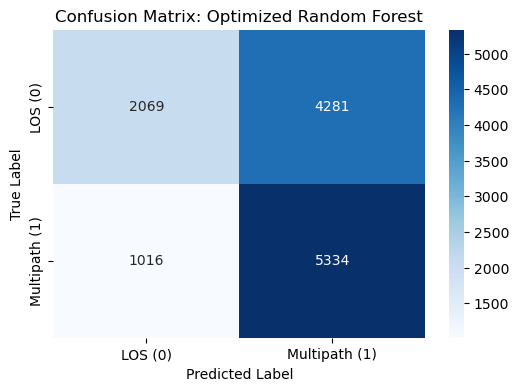

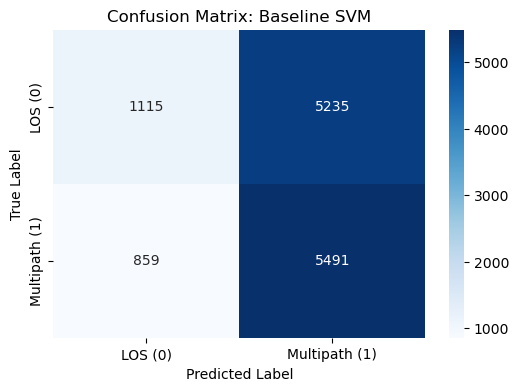

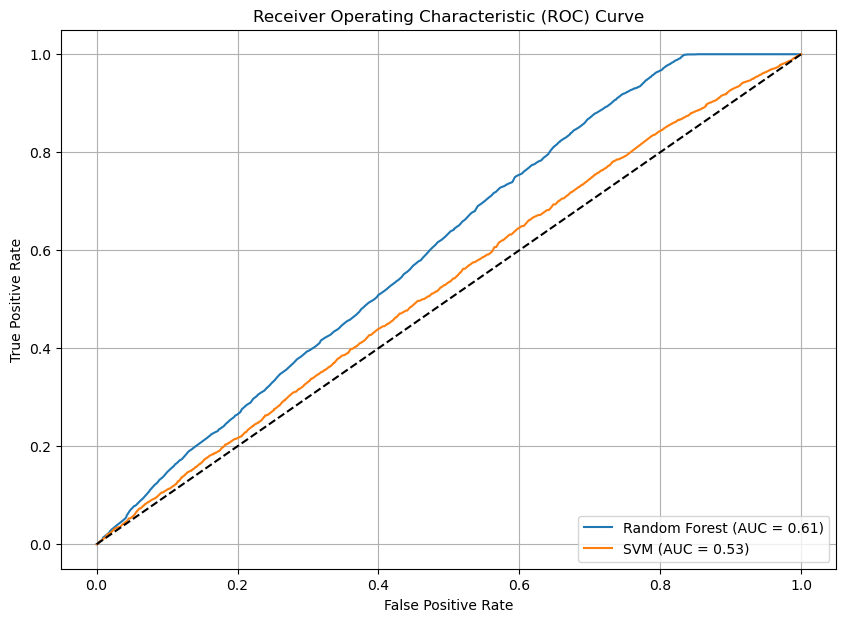

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    """Calculates and prints classification metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- {model_name} Metrics ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")
    
    return f1

# Evaluate both models
f1_rf = evaluate_model(y_test, y_pred_rf, "Optimized Random Forest")
f1_svm = evaluate_model(y_test, y_pred_svm, "Baseline SVM")

# Plot Confusion Matrices
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plots a confusion matrix using a Seaborn heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['LOS (0)', 'Multipath (1)'], 
                yticklabels=['LOS (0)', 'Multipath (1)'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, "Optimized Random Forest")
plot_confusion_matrix(y_test, y_pred_svm, "Baseline SVM")

# Plot ROC Curve
plt.figure(figsize=(10, 7))

# Random Forest ROC
y_prob_rf = best_rf_clf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# SVM ROC
y_prob_svm = svm_clf.predict_proba(X_test)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.2f})')

# Plotting details
plt.plot([0, 1], [0, 1], 'k--') # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# Step 7: Feature Importance Analysis
Extract and visualize the feature importances from the optimized Random Forest model.

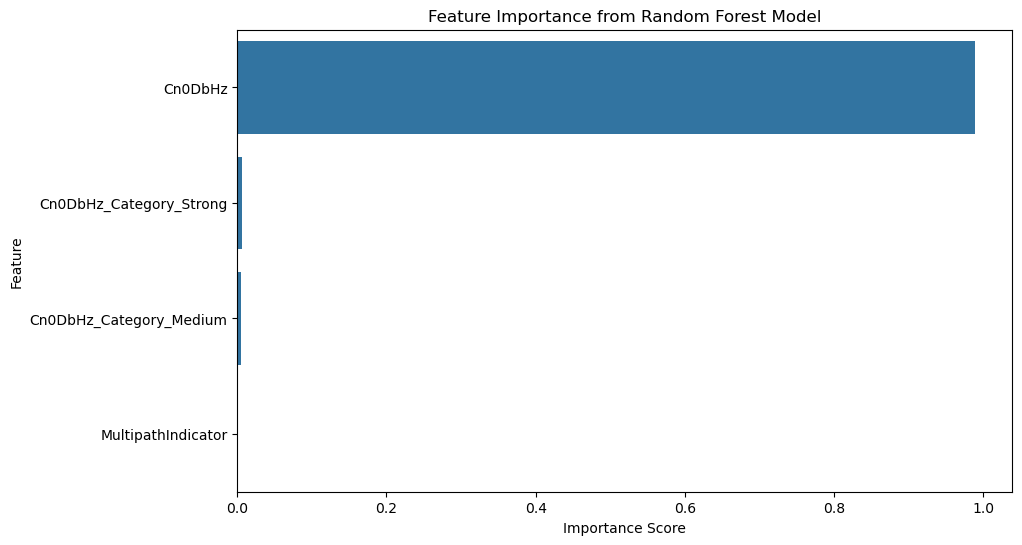

                   Feature  Importance
0                  Cn0DbHz    0.989290
3  Cn0DbHz_Category_Strong    0.005791
2  Cn0DbHz_Category_Medium    0.004919
1       MultipathIndicator    0.000000


In [14]:
# Get feature importances
importances = best_rf_clf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(feature_importance_df)

# Step 8: Generating the AI-Corrected Trajectory
Apply the best-performing model to the entire original dataset to filter out multipath interference and export the corrected trajectory.

In [19]:
# Determine the best model based on F1-score
best_model = best_rf_clf if f1_rf > f1_svm else svm_clf
print(f"The best performing model is: {type(best_model).__name__}")

# Load the original unfiltered trajectory data
unfiltered_path = '../../GNSS_Multipath_Project/data/02_interim/time_synced_epochs.csv'
df_unfiltered = pd.read_csv(unfiltered_path)

print("\nOriginal unfiltered data loaded:")
print(df_unfiltered.head())

# Preprocess the unfiltered data to create the same features used in training
# 1. Create Cn0DbHz categories
def categorize_cn0(cn0):
    if cn0 < 20:
        return 'Weak'
    elif 20 <= cn0 < 35:
        return 'Medium'
    else:
        return 'Strong'

df_unfiltered['Cn0DbHz_Category'] = df_unfiltered['Cn0DbHz'].apply(categorize_cn0)

# 2. One-hot encode the category
df_unfiltered = pd.get_dummies(df_unfiltered, columns=['Cn0DbHz_Category'], prefix='Cn0DbHz_Category')

# Ensure all feature columns exist, fill missing with 0 (in case a category isn't present in the unfiltered data)
for col in features:
    if col not in df_unfiltered.columns:
        df_unfiltered[col] = 0

# Ensure the unfiltered data has the required features in the correct order
X_unfiltered = df_unfiltered[features]

# Generate predictions for the entire dataset
df_unfiltered['is_multipath_pred'] = best_model.predict(X_unfiltered)

# Filter the DataFrame to keep only clean (LOS) signals
df_corrected = df_unfiltered[df_unfiltered['is_multipath_pred'] == 0].copy()

# Select essential columns for the final output
output_columns = [
    'UnixTimeMillis', 
    'LatitudeDegrees', 'LongitudeDegrees', 
    'AltitudeMeters', 'TruthLatitudeDegrees', 'TruthLongitudeDegrees'
]
# Check which of the desired columns are actually in the dataframe
final_columns = [col for col in output_columns if col in df_corrected.columns]

df_final_track = df_corrected[final_columns]

# Define the output path
output_dir = '../../GNSS_Multipath_Project/data/03_processed/'
output_filename = 'ai_corrected_track.csv'
output_path = os.path.join(output_dir, output_filename)

# Export the corrected trajectory to a CSV file
df_final_track.to_csv(output_path, index=False)

print(f"\nAI-corrected trajectory saved to: {output_path}")
print(f"Number of points in original track: {len(df_unfiltered)}")
print(f"Number of points in corrected track: {len(df_final_track)}")
print(f"Number of points removed: {len(df_unfiltered) - len(df_final_track)}")

The best performing model is: RandomForestClassifier

Original unfiltered data loaded:
        TimeNanos        FullBiasNanos  State  ReceivedSvTimeUncertaintyNanos  \
0  21092250000000 -1273508372192433389  23567                               8   
1  21092250000000 -1273508372192433389  23567                              14   
2  21092250000000 -1273508372192433389  23567                               6   
3  21092250000000 -1273508372192433389  23567                              21   
4  21092250000000 -1273508372192433389  23567                               8   

   Cn0DbHz  MultipathIndicator  AccumulatedDeltaRangeState     GpsTimeNanos  \
0     36.6                   0                          25  425464442433280   
1     30.8                   0                          25  425464442433280   
2     38.7                   0                          25  425464442433280   
3     26.7                   0                          27  425464442433280   
4     36.0                   0 